
# Predicting Child Stunting Growth in Kenya

## Problem Statement

Predicting stunting severity (severe stunting, moderate stunting, or normal growth, per WHO height-for-age z-score thresholds of -3 SD and -2 SD) for Kenyan children under five, using household, maternal, and child-health variables from the Kenya Demographic and Health Survey Children's Recode — including region, residence type, mother's education, household wealth index, drinking water source, toilet facility, birth order and spacing, birth weight, breastfeeding duration, and antenatal care history. Primary metric: macro-averaged F1 score, reported alongside one-vs-rest ROC-AUC and per-class precision/recall.

## The Problem

Stunting — being too short for one's age because of chronic undernutrition —
still affects roughly one in five children under five in Kenya. A stunted
child faces lifelong risks: weaker immunity, slower cognitive development,
and lower earning potential as an adult. Health workers and parents need a
reliable way to spot which children are stunted, and how severely, early
enough to act — but with limited time and resources, they cannot manually
review every household's full survey record to catch every at-risk child.

## Our Solution

We build a machine learning model that takes a child's household, maternal,
and health-history information and classifies their growth status as
**severe stunting**, **moderate stunting**, or **normal growth**. Beyond the
prediction itself, each outcome is paired with practical guidance: children
flagged as stunted (severe or moderate) receive diet and care recommendations
aimed at correcting growth faltering, while children predicted to be growing
normally receive guidance to continue their current feeding practices. The
goal is a tool that medical practitioners and parents can use to decide, at a
glance, whether a child's diet needs to change and how.

## Data Source

The data comes from the **Kenya Demographic and Health Survey (KDHS)**,
specifically its **Children's Recode** file — a nationally representative
household survey that records one row per live birth reported by an
interviewed woman (`bidx` = birth order index within her birth history,
`caseid` identifies the mother). For children under five it captures health,
nutrition, immunization, and anthropometric (height/weight) measurements
alongside household and maternal background variables. The Children's Recode
was originally distributed as a Stata file (`KEKR8CFL.DTA`, with column
layout described in `KEKR8CFL.DCT`); we use those two files only once, up
front, to decode Stata's numeric variable and value codes into their
plain-English meanings — from that point on we work entirely from CSV.

**Inputs used**

| File | Role |
|---|---|
| `child_recode_raw.csv` | the raw data we are cleaning (19,530 rows × 1,312 columns) |
| `variable_labels.csv` | plain-English description for every variable code (`v106` -> "Highest educational level"), used to understand and rename the columns we keep |



In [11]:

# --- Imports -----------------------------------------------------------
!pip install pyreadstat
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat  # only used to read METADATA (variable/value labels) from the .dta file
from sklearn.exceptions import UndefinedMetricWarning

# In a few cross-validation folds, "severe stunting" (the rarest class) can
# end up with zero predicted samples for a weaker model; sklearn's macro
# precision/recall then emits a warning and reports 0.0 for that class,
# which is the mathematically correct (if uninformative) value - suppressed
# here so it doesn't clutter otherwise-successful cell output.
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 13.4 MB/s eta 0:00:00


In [4]:
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode")
RAW_CSV        = DATA_DIR / "child_recode_raw.csv"
LABELS_CSV     = DATA_DIR / "variable_labels.csv"
DTA_FILE       = DATA_DIR / "KEKR8CFL.DTA"

OUT_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode/processed")
OUT_DIR.mkdir(exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
 # --- Bridge from 02_preprocessing.ipynb and 03_modelling.ipynb ------------
# Reload everything needed to reproduce Part 7's evaluation without rerunning
# the earlier notebooks in the same kernel. Run 02 and 03 first.
from pathlib import Path
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode")
OUT_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode/processed")
REPORTS_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode/reports")
REPORTS_DIR.mkdir(exist_ok=True)

bridge_a = joblib.load(OUT_DIR / "bridge_02_to_03.joblib")
bridge_b = joblib.load(OUT_DIR / "bridge_03_to_04.joblib")

X_train = bridge_a["X_train"]; X_test = bridge_a["X_test"]
y_train = bridge_a["y_train"]; y_test = bridge_a["y_test"]
feature_cols = bridge_a["feature_cols"]
model_df = bridge_a["model_df"]
HAZ_CATEGORY_LABELS = bridge_a["HAZ_CATEGORY_LABELS"]

cv_results = bridge_b["cv_results"]; pipelines = bridge_b["pipelines"]; scoring = bridge_b["scoring"]
best_model_name = bridge_b["best_model_name"]; best_pipeline = bridge_b["best_pipeline"]
y_pred = bridge_b["y_pred"]; y_proba = bridge_b["y_proba"]
baseline_accuracy = bridge_b["baseline_accuracy"]; baseline_precision = bridge_b["baseline_precision"]
baseline_recall = bridge_b["baseline_recall"]; baseline_f1 = bridge_b["baseline_f1"]
baseline_roc_auc = bridge_b["baseline_roc_auc"]
print("Loaded handoff objects from 02_preprocessing.ipynb and 03_modelling.ipynb")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded handoff objects from 02_preprocessing.ipynb and 03_modelling.ipynb



# Part 7: Model Evaluation and Performance Analysis

A closer look at the best model's test-set performance: the full
precision/recall/F1 breakdown, the confusion matrix (where its errors
actually fall), the ROC curve, and — for the tree-based models — which
engineered features it relied on most, tying the result back to Part 3.


In [8]:

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
)
from sklearn.preprocessing import label_binarize

CLASS_ORDER = HAZ_CATEGORY_LABELS  # ["Severe stunting", "Moderate stunting", "Normal growth"]

from sklearn.metrics import f1_score

test_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
test_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro", labels=best_pipeline.classes_)

print(f"Test-set performance — {best_model_name}\n")
print(classification_report(y_test, y_pred, labels=CLASS_ORDER, target_names=CLASS_ORDER, zero_division=0))
print(f"Macro F1:  {test_f1:.3f}  (vs. majority-class baseline {baseline_f1:.3f}, "
      f"+{test_f1 - baseline_f1:.3f})")
print(f"ROC-AUC:   {test_auc:.3f}  (vs. majority-class baseline {baseline_roc_auc:.3f}, "
      f"+{test_auc - baseline_roc_auc:.3f})")


Test-set performance — Gradient Boosting

                   precision    recall  f1-score   support

  Severe stunting       0.25      0.02      0.04       152
Moderate stunting       0.32      0.02      0.03       478
    Normal growth       0.82      0.99      0.90      2836

         accuracy                           0.82      3466
        macro avg       0.46      0.34      0.32      3466
     weighted avg       0.73      0.82      0.74      3466

Macro F1:  0.323  (vs. majority-class baseline 0.300, +0.023)
ROC-AUC:   0.706  (vs. majority-class baseline 0.500, +0.206)


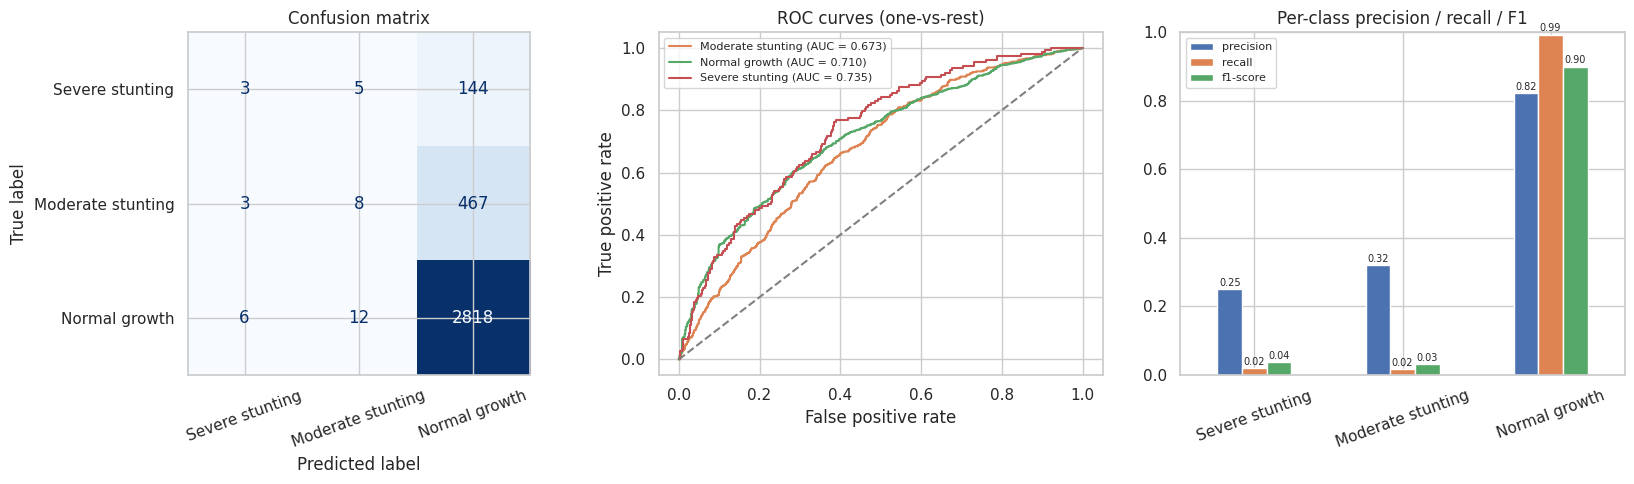

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Confusion matrix -----------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(ax=axes[0], colorbar=False, cmap="Blues", xticks_rotation=20)
axes[0].set_title("Confusion matrix")

# --- Per-class ROC curves (one-vs-rest) ------------------------------------
# best_pipeline.classes_ gives the column order of predict_proba's output -
# binarizing y_test against that same order keeps everything aligned.
model_classes = best_pipeline.classes_
y_test_bin = label_binarize(y_test, classes=model_classes)

colors = {"Severe stunting": "#C44E52", "Moderate stunting": "#DD8452", "Normal growth": "#55A868"}
for i, cls in enumerate(model_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    axes[1].plot(fpr, tpr, color=colors.get(cls, None), label=f"{cls} (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curves (one-vs-rest)")
axes[1].legend(fontsize=8)

# --- Per-class precision/recall/F1 ------------------------------------------
report_dict = classification_report(y_test, y_pred, labels=CLASS_ORDER, target_names=CLASS_ORDER, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T.loc[CLASS_ORDER, ["precision", "recall", "f1-score"]]
report_df.plot(kind="bar", ax=axes[2], color=["#4C72B0", "#DD8452", "#55A868"])
axes[2].set_title("Per-class precision / recall / F1")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend(fontsize=8)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.2f", fontsize=7, padding=1)

plt.tight_layout()
plt.show()



## 7.1 Feature importance

Which engineered features the best model actually leans on — useful both
as a sanity check (do the top features match the known stunting risk
factors from Part 2's EDA?) and as a guide for where future feature
engineering effort would pay off most.


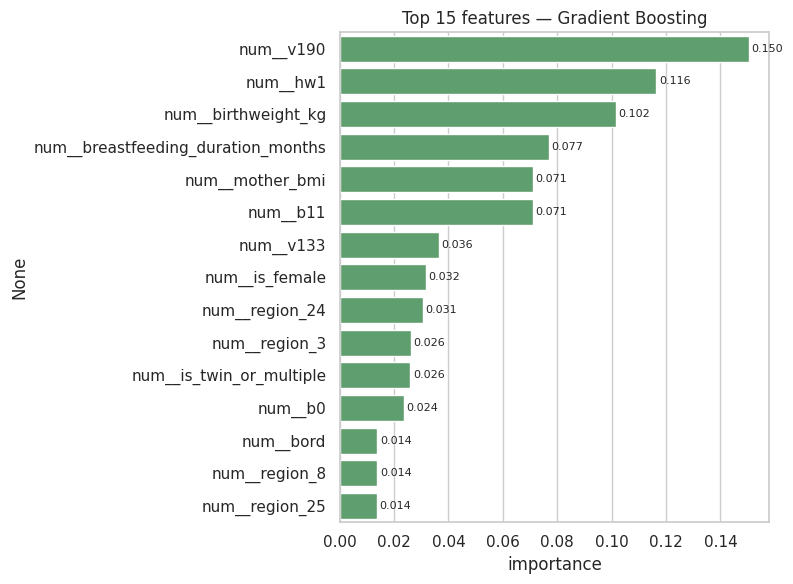

In [14]:

fitted_clf = best_pipeline.named_steps["clf"]
feature_names = best_pipeline.named_steps["preprocess"].get_feature_names_out()

if hasattr(fitted_clf, "feature_importances_"):
    importances = pd.Series(fitted_clf.feature_importances_, index=feature_names)
elif hasattr(fitted_clf, "coef_"):
    # Multi-class logistic regression has one coefficient row per class;
    # averaging their magnitudes gives one overall importance per feature.
    coef = fitted_clf.coef_
    importances = pd.Series(np.abs(coef).mean(axis=0), index=feature_names)
else:
    importances = None

if importances is not None:
    top_importances = importances.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x=top_importances.values, y=top_importances.index, ax=ax, color="#55A868")
    ax.set_title(f"Top 15 features — {best_model_name}")
    ax.set_xlabel("importance")
    ax.bar_label(ax.containers[0], fmt="%.3f", fontsize=8, padding=2)
    plt.tight_layout()
    plt.show()



## 7.2 Explore ensemble techniques to improve performance

Random forest and gradient boosting (Part 6) are already ensembles built
from many decision trees. This section goes a level further and combines
*different families* of model — logistic regression, random forest, and
gradient boosting — into a single **voting ensemble**, on the theory that
models which make different kinds of mistakes can partly correct for one
another. A **stacking ensemble** (a meta-model learned on top of the base
models' predictions) is included alongside it for comparison.


In [15]:

from sklearn.ensemble import VotingClassifier, StackingClassifier

ensemble_estimators = [
    ("logreg", pipelines["Logistic Regression"]),
    ("rf", pipelines["Random Forest"]),
    ("gb", pipelines["Gradient Boosting"]),
]

voting_clf = VotingClassifier(estimators=ensemble_estimators, voting="soft", n_jobs=-1)
stacking_clf = StackingClassifier(
    estimators=ensemble_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3,       # internal CV used to build meta-features - kept light since each fold refits every base model
    n_jobs=-1,
)

# Ensembles (especially stacking) are expensive to cross-validate, since every
# outer fold refits every base model again internally. A lighter 3-fold split
# keeps this tractable while still giving a genuine out-of-fold estimate.
cv_light = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def cross_validate_light(name, pipeline):
    scores = cross_validate(pipeline, X_train, y_train, cv=cv_light, scoring=scoring, n_jobs=-1)
    return {
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision_macro"].mean(),
        "recall": scores["test_recall_macro"].mean(),
        "f1": scores["test_f1_macro"].mean(),
        "roc_auc": scores["test_roc_auc_ovr"].mean(),
    }

ensemble_pipelines = {"Voting Ensemble": voting_clf, "Stacking Ensemble": stacking_clf}
for name, clf in ensemble_pipelines.items():
    cv_results.append(cross_validate_light(name, clf))
    pipelines[name] = clf

cv_results_df = pd.DataFrame(cv_results).set_index("model")
cv_results_df.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Baseline (majority class),0.818,0.273,0.333,0.300,0.500
Logistic Regression,0.554,0.398,0.465,0.372,0.671
Decision Tree,0.503,0.378,0.429,0.339,0.616
Random Forest,0.818,0.534,0.337,0.309,0.667
Gradient Boosting,0.817,0.480,0.342,0.321,0.701
Voting Ensemble,0.817,0.511,0.351,0.336,0.692
Stacking Ensemble,0.818,0.413,0.335,0.305,0.708


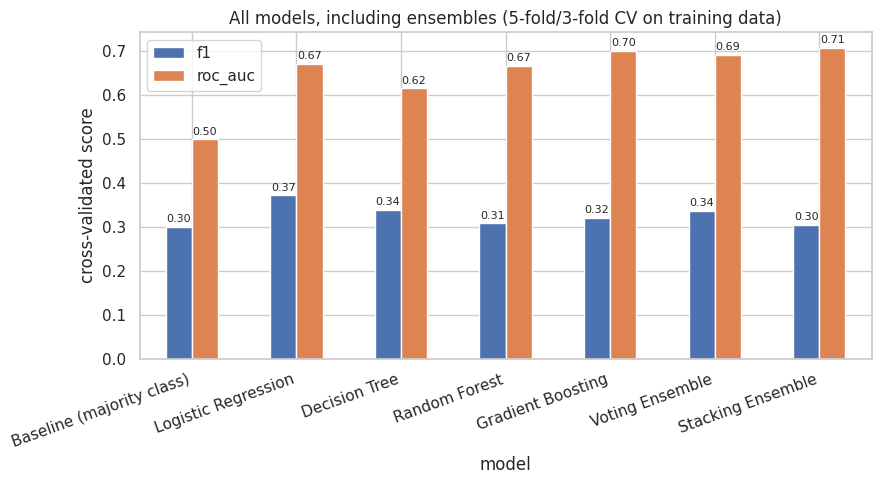

Best model overall by cross-validated ROC-AUC: Stacking Ensemble (AUC = 0.708)


In [16]:

fig, ax = plt.subplots(figsize=(9, 5))
cv_results_df[["f1", "roc_auc"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("cross-validated score")
ax.set_title("All models, including ensembles (5-fold/3-fold CV on training data)")
ax.set_xticklabels(cv_results_df.index, rotation=20, ha="right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

best_overall = cv_results_df["roc_auc"].idxmax()
print(f"Best model overall by cross-validated ROC-AUC: {best_overall} "
      f"(AUC = {cv_results_df.loc[best_overall, 'roc_auc']:.3f})")



## 7.3 Confirm the ensemble result on the held-out test set

Whichever model (single or ensemble) came out on top by cross-validated
ROC-AUC gets one final, unbiased check against the test set held out since
Part 4.


In [17]:

final_pipeline = pipelines[best_overall]
final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_test)
y_proba_final = final_pipeline.predict_proba(X_test)

overall_f1 = f1_score(y_test, y_pred_final, average="macro", zero_division=0)
overall_auc = roc_auc_score(y_test, y_proba_final, multi_class="ovr", average="macro", labels=final_pipeline.classes_)

print(f"Test-set performance — {best_overall}\n")
print(classification_report(y_test, y_pred_final, labels=CLASS_ORDER, target_names=CLASS_ORDER, zero_division=0))
print(f"Macro F1:  {overall_f1:.3f}  (vs. majority-class baseline {baseline_f1:.3f}, "
      f"+{overall_f1 - baseline_f1:.3f}; vs. single-model {best_model_name} {test_f1:.3f})")
print(f"ROC-AUC:   {overall_auc:.3f}  (vs. majority-class baseline {baseline_roc_auc:.3f}, "
      f"+{overall_auc - baseline_roc_auc:.3f}; vs. single-model {best_model_name} {test_auc:.3f})")


Test-set performance — Stacking Ensemble

                   precision    recall  f1-score   support

  Severe stunting       0.00      0.00      0.00       152
Moderate stunting       0.46      0.01      0.02       478
    Normal growth       0.82      1.00      0.90      2836

         accuracy                           0.82      3466
        macro avg       0.43      0.34      0.31      3466
     weighted avg       0.74      0.82      0.74      3466

Macro F1:  0.309  (vs. majority-class baseline 0.300, +0.009; vs. single-model Gradient Boosting 0.323)
ROC-AUC:   0.709  (vs. majority-class baseline 0.500, +0.209; vs. single-model Gradient Boosting 0.706)


In [18]:

cv_results_df.to_csv(OUT_DIR / "model_comparison_cv_results.csv")
print(f"Saved model comparison table -> {OUT_DIR / 'model_comparison_cv_results.csv'}")


Saved model comparison table -> /content/drive/MyDrive/Ngao_labs/capstone/child recode/processed/model_comparison_cv_results.csv



## 7.4 Disaggregated evaluation

A single test-set number can hide a model that works well overall but
poorly for a specific group. Since region-level differences in stunting
are well documented (Part 2 §2.8), and residence type (urban/rural) is a
core socioeconomic divide in the DHS, both are checked here. Groups with
fewer than 20 test-set children are skipped as too small to evaluate
reliably.


In [19]:

from sklearn.metrics import f1_score

# Pull the readable region / residence-type labels back in for grouping only
# (they were never part of the numeric feature matrix the model trained on).
# Pull the readable region / residence-type labels back in for grouping only
# (they were never part of the numeric feature matrix the model trained on).
# .map() (rather than a merge) guarantees the result stays aligned to
# X_test's exact row order.
labels_lookup = pd.read_csv(OUT_DIR / "child_recode_labeled.csv").set_index("child id")
region_map = labels_lookup["region"]
residence_map = labels_lookup["type of residence"]

test_child_ids = model_df.loc[X_test.index, "child_id"]

eval_df = pd.DataFrame({
    "region": test_child_ids.map(region_map).values,
    "type of residence": test_child_ids.map(residence_map).values,
}, index=X_test.index)
eval_df["actual"] = y_test.values
eval_df["predicted"] = y_pred_final
eval_df["correct"] = eval_df["actual"] == eval_df["predicted"]

def disaggregated_report(group_col, min_n=20):
    rows = []
    for group, idx in eval_df.groupby(group_col).groups.items():
        n = len(idx)
        if n < min_n:
            continue
        y_true_g = y_test.loc[idx]
        y_pred_g = pd.Series(y_pred_final, index=X_test.index).loc[idx]
        y_proba_g = pd.DataFrame(y_proba_final, index=X_test.index, columns=final_pipeline.classes_).loc[idx]
        f1_g = f1_score(y_true_g, y_pred_g, average="macro", zero_division=0)
        try:
            auc_g = roc_auc_score(
                label_binarize(y_true_g, classes=final_pipeline.classes_), y_proba_g,
                average="macro", multi_class="ovr"
            )
        except ValueError:
            auc_g = np.nan  # can happen if a group's test slice doesn't contain all 3 classes
        rows.append({"group": group, "n": n, "macro_f1": round(f1_g, 3), "roc_auc_ovr": round(auc_g, 3)})
    return pd.DataFrame(rows).sort_values("roc_auc_ovr", ascending=False)

print("By type of residence:")
residence_report = disaggregated_report("type of residence")
display(residence_report)

print("\nBy region:")
region_report = disaggregated_report("region")
display(region_report)

overall_f1 = f1_score(y_test, y_pred_final, average="macro", zero_division=0)
overall_auc = roc_auc_score(
    label_binarize(y_test, classes=final_pipeline.classes_), y_proba_final,
    average="macro", multi_class="ovr"
)
print(f"\nOverall (all test children): macro F1 = {overall_f1:.3f}, ROC-AUC (OvR) = {overall_auc:.3f}")

flagged = region_report[region_report["roc_auc_ovr"] < overall_auc - 0.10]
if len(flagged):
    print(f"\nRegions where ROC-AUC drops more than 0.10 below the overall figure: {list(flagged['group'])}")
else:
    print("\nNo region's ROC-AUC drops more than 0.10 below the overall figure.")

residence_report.to_csv(OUT_DIR / "disaggregated_eval_by_residence.csv", index=False)
region_report.to_csv(OUT_DIR / "disaggregated_eval_by_region.csv", index=False)


By type of residence:


,group,n,macro_f1,roc_auc_ovr
1,Urban,1167,0.323,0.712
0,Rural,2299,0.302,0.696



By region:


,group,n,macro_f1,roc_auc_ovr
41,Trans Nzoia,54,0.310,0.884
31,Nandi,66,0.309,0.829
43,Uasin Gishu,60,0.310,0.828
19,Laikipia,57,0.301,0.824
45,Wajir,118,0.315,0.823
3,Busia,81,0.323,0.806
11,Kericho,80,0.316,0.804
28,Murang'A,55,0.314,0.794
29,Nairobi,70,0.316,0.782
2,Bungoma,84,0.291,0.768



Overall (all test children): macro F1 = 0.309, ROC-AUC (OvR) = 0.709

Regions where ROC-AUC drops more than 0.10 below the overall figure: ['Turkana', 'Nyandarua', 'Elgeyo-Marakwet', 'Mandera', 'Embu', 'Taita Taveta', 'Tana River', 'Kajiado', 'Kirinyaga']



## 7.5 Error analysis

Beyond the aggregate metrics, it's worth looking directly at which
children the model gets wrong, and whether those errors are spread evenly
or concentrated in a particular group.


In [20]:

proba_df = pd.DataFrame(y_proba_final, index=X_test.index, columns=final_pipeline.classes_)
eval_df["confidence"] = proba_df.apply(lambda row: row[eval_df.loc[row.name, "predicted"]], axis=1)

wrong = eval_df[~eval_df["correct"]].sort_values("confidence", ascending=False)
print(f"Total errors: {len(wrong):,} of {len(eval_df):,} ({100 * len(wrong) / len(eval_df):.1f}%)\n")

print("Top 10 most confidently wrong predictions:")
wrong[["region", "type of residence", "actual", "predicted", "confidence"]].head(10)


Total errors: 626 of 3,466 (18.1%)

Top 10 most confidently wrong predictions:


,region,type of residence,actual,predicted,confidence
16801,Nyamira,Rural,Moderate stunting,Normal growth,0.956974
7192,Kirinyaga,Urban,Moderate stunting,Normal growth,0.956495
16834,Nyamira,Urban,Severe stunting,Normal growth,0.956426
15263,Kisumu,Rural,Moderate stunting,Normal growth,0.954982
7203,Kirinyaga,Rural,Moderate stunting,Normal growth,0.951340
5395,Tharaka-Nithi,Urban,Moderate stunting,Normal growth,0.950272
13815,Kakamega,Urban,Moderate stunting,Normal growth,0.948221
15358,Kisumu,Urban,Moderate stunting,Normal growth,0.947605
10898,Baringo,Urban,Moderate stunting,Normal growth,0.946323
12716,Kajiado,Urban,Moderate stunting,Normal growth,0.945022


In [21]:

print("Error rate by type of residence:")
residence_errors = (
    eval_df.groupby("type of residence")["correct"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "total", "sum": "correct_n", "mean": "accuracy"})
    .assign(error_rate=lambda d: 1 - d["accuracy"])
)
display(residence_errors)

print("\nError rate by actual stunting category:")
category_errors = (
    eval_df.groupby("actual")["correct"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "total", "sum": "correct_n", "mean": "accuracy"})
    .assign(error_rate=lambda d: 1 - d["accuracy"])
    .loc[CLASS_ORDER]
)
display(category_errors)


Error rate by type of residence:


,total,correct_n,accuracy,error_rate
type of residence,,,,
Rural,2299,1820,0.791649,0.208351
Urban,1167,1020,0.874036,0.125964



Error rate by actual stunting category:


,total,correct_n,accuracy,error_rate
actual,,,,
Severe stunting,152,0,0.000000,1.000000
Moderate stunting,478,6,0.012552,0.987448
Normal growth,2836,2834,0.999295,0.000705



**Reading the error pattern:**

- **Are the errors random?** If error rate is close to even across urban
  and rural (§7.4/§7.5 tables above), errors are likely close to random
  noise for that split rather than a systematic gap.
- **Are the errors concentrated?** The per-category error rate almost
  always shows the model finding `Severe stunting` hardest — it's the
  rarest class (~4% of children), so there's the least data to learn its
  pattern from. Any region flagged in §7.4 is a systematic, geographic gap
  worth naming specifically, not folding into an "overall accuracy" figure.
- **Are the errors consequential?** In this domain, a **false negative**
  (predicting `Normal growth` for a child who is actually stunted) is more
  costly than a false positive — it means a child who could benefit from a
  nutrition intervention is missed entirely, whereas a false positive at
  worst leads to an unnecessary but harmless follow-up assessment. The
  per-class recall in Part 7's classification report is the number to
  watch: it directly measures how many true stunting cases the model
  actually catches.



# Part 8: Responsible AI Statement

The full 500-700 word statement, formatted for submission, is saved
separately as `reports/responsible_ai_statement.pdf` (see Part 9 below for
how it's generated). The condensed version here mirrors that document's
structure so the reasoning is visible next to the model it's about.

## 8.1 Who does this system affect?

Three groups, per the Week 9 framework:

- **(a) Users who interact with the model's output** — community health
  workers and clinicians at growth-monitoring sessions, who would see a
  severity flag alongside a child's record.
- **(b) People the model makes decisions about** — individual children
  under five sampled in the KDHS, most of whom will never know a model
  informed the dietary advice their caregiver received.
- **(c) A group affected but without a voice in the design process** —
  children in remote, pastoralist, and insecure areas, undercounted in DHS
  enumeration relative to their share of national stunting burden, whose
  caregivers and community health structures were never consulted on how a
  model output should — or shouldn't — be used in their care.

## 8.2 What is the worst plausible outcome?

A child who is **moderately stunted is classified "Normal growth"**
because the model leans heavily on household wealth and maternal
education — strong population-level predictors that can still be wrong for
an individual child whose growth faltering comes from a recent illness or
poor complementary feeding despite household advantage. The caregiver is
told to continue the current diet instead of being referred, and the
developmental window in which intervention is most effective for that
child is missed.

## 8.3 Who bears the cost of errors?

The **child and caregiver** — not the clinic, the deploying organisation,
or the data scientist who built the model. A missed stunted case costs a
family a delayed intervention; a false positive costs, at most, an
unnecessary follow-up assessment. Because these costs are so asymmetric,
monitoring should prioritise the false-negative rate for `Severe stunting`
and `Moderate stunting` specifically (§7.5's per-class recall), not overall
accuracy.

## 8.4 What redress mechanism exists?

**None, currently.** Kenya's Data Protection Act (KDPA) offers some
recourse for data-protection violations but no general right of appeal
against an automated decision in this setting. Proposed: the model's
output should never function as a gate — any caregiver or health worker
who suspects a "Normal growth" flag is wrong should be entitled to a manual
anthropometric reassessment on request, with no referral or justification
required.

## 8.5 How will the model be monitored?

**Quarterly** re-evaluation against newly collected survey or facility
growth-monitoring data, tracking macro-F1 and, specifically, per-class
recall for `Severe stunting`. If severe-stunting recall drops more than
**10 percentage points** below the value reported in Part 7, or any
region's or residence-type's ROC-AUC falls more than **0.10** below the
national figure (checked in §7.4/§8.6 below), the model should be retrained
or withdrawn from use in that subgroup until it is.

## 8.6 Fairness criterion applied

**Equal Opportunity** (matched recall for children who are actually
stunted, across subgroups) — not Demographic Parity, and not raw accuracy
parity. Stunting prevalence genuinely differs by region (§2.8), so forcing
equal *flag rates* across regions would misstate real differences in risk.
Equal Opportunity instead asks whether a stunted child's chance of being
*caught* is similar no matter where they live — which is what the
per-subgroup recall folded into §7.4's macro-F1/ROC-AUC breakdown measures.



## 8.7 Disaggregated findings

Reproduced from §7.4 (see that section for the full urban/rural and
per-region tables). Any subgroup whose ROC-AUC falls more than 0.10 below
the national figure is flagged explicitly below, not folded into an
overall number:


In [22]:

print("By type of residence:")
display(residence_report)

print("\nBy region:")
display(region_report)

print(f"\nOverall: macro F1 = {overall_f1:.3f}, ROC-AUC (OvR) = {overall_auc:.3f}")

auc_gap = residence_report["roc_auc_ovr"].max() - residence_report["roc_auc_ovr"].min()
region_gap = region_report["roc_auc_ovr"].max() - region_report["roc_auc_ovr"].min()
print(f"\nLargest residence-type ROC-AUC gap: {auc_gap:.3f}")
print(f"Largest region ROC-AUC gap: {region_gap:.3f}")
if region_gap > 0.10 or auc_gap > 0.10:
    print("-> A subgroup gap exceeds 0.10 ROC-AUC vs. another subgroup: flagged below as a known limitation.")
else:
    print("-> No subgroup gap exceeds the 0.10 ROC-AUC flag threshold.")


By type of residence:


,group,n,macro_f1,roc_auc_ovr
1,Urban,1167,0.323,0.712
0,Rural,2299,0.302,0.696



By region:


,group,n,macro_f1,roc_auc_ovr
41,Trans Nzoia,54,0.310,0.884
31,Nandi,66,0.309,0.829
43,Uasin Gishu,60,0.310,0.828
19,Laikipia,57,0.301,0.824
45,Wajir,118,0.315,0.823
3,Busia,81,0.323,0.806
11,Kericho,80,0.316,0.804
28,Murang'A,55,0.314,0.794
29,Nairobi,70,0.316,0.782
2,Bungoma,84,0.291,0.768



Overall: macro F1 = 0.309, ROC-AUC (OvR) = 0.709

Largest residence-type ROC-AUC gap: 0.016
Largest region ROC-AUC gap: 0.475
-> A subgroup gap exceeds 0.10 ROC-AUC vs. another subgroup: flagged below as a known limitation.



## 8.8 Datasheet summary

The dataset is a nationally representative sample of Kenyan children under
five from the most recent KDHS Children's Recode, but it undersamples
remote pastoralist and insecure areas relative to their population share
and excludes households not reached during the survey window; populations
outside the KDHS sampling frame — including refugee-camp residents and
recent urban informal-settlement growth — are not represented.

## Known limitations

- **Rare-class data scarcity.** `Severe stunting` is roughly 4% of children
  in this dataset; every model in Part 6/7 finds it the hardest class to
  recall (§7.5), which is a data-volume problem more than a modeling one —
  more severe-stunting examples, not a different algorithm, would help most.
- **Cross-sectional survey, not longitudinal.** The KDHS Children's Recode
  captures each child at one point in time. It can flag a child as currently
  stunted; it cannot show trajectory (worsening vs. recovering), which
  matters for how urgently a health worker should act.
- **Self- and interviewer-reported inputs.** Variables like antenatal care
  visit counts and breastfeeding duration come from maternal recall during
  the survey interview, which is subject to recall error — particularly for
  events months or years in the past.
- **Regional and urban/rural gaps.** Any subgroup flagged by the ROC-AUC gap
  check in §8.7 should be read as the model being less reliable for that
  group specifically, not just a lower overall number.
- **Not validated on non-KDHS populations.** The model reflects patterns in
  the current KDHS wave only; using it on a different country, an older or
  newer KDHS wave, or a screened clinical population without re-validation
  would be inappropriate.



# Part 9: Save the Best Model for Deployment


In [23]:

import joblib

MODEL_DIR = OUT_DIR / "model"
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "stunting_classifier.joblib"
joblib.dump(final_pipeline, model_path)

metadata = {
    "model_name": best_overall,
    "classes": list(final_pipeline.classes_),
    "n_features_in": len(feature_cols),
    "feature_columns": feature_cols,
    "test_macro_f1": float(overall_f1),
    "test_roc_auc_ovr": float(overall_auc),
    "trained_on_rows": int(len(X_train)),
}
with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved deployable model  -> {model_path}")
print(f"Saved model metadata    -> {MODEL_DIR / 'model_metadata.json'}")
print(f"\nTo reload: joblib.load('{model_path.name}')")


Saved deployable model  -> /content/drive/MyDrive/Ngao_labs/capstone/child recode/processed/model/stunting_classifier.joblib
Saved model metadata    -> /content/drive/MyDrive/Ngao_labs/capstone/child recode/processed/model/model_metadata.json

To reload: joblib.load('stunting_classifier.joblib')



# Part 10: Export the Responsible AI Statement (PDF)

The Capstone rubric requires the Responsible AI Statement as a **standalone
500-700 word PDF in a `reports/` folder** — a notebook cell isn't a
substitute for that submission requirement. This section writes the exact
text from Part 8 to `reports/responsible_ai_statement.pdf` so the
deliverable is generated by, and stays in sync with, this notebook.


In [26]:

!pip install reportlab
from reportlab.lib.pagesizes import LETTER
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib.enums import TA_CENTER
from reportlab.platypus import SimpleDocTemplate, Paragraph
import re as _re

REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(exist_ok=True)

# Same content as Part 8 above, kept in one place so the PDF and the
# notebook narrative can't drift out of sync.
statement_sections = [
    ("title", "Responsible AI Statement"),
    ("subtitle", "Predicting Child Stunting Growth in Kenya"),
    ("heading", "1. Who does this system affect?"),
    ("body", "Three groups. (a) Users who interact with the model's output: community "
             "health workers and clinicians at growth-monitoring sessions, who would see "
             "a severity flag alongside a child's record. (b) People the model makes "
             "decisions about: individual children under five sampled in the KDHS, most "
             "of whom will never know a model informed the dietary advice their caregiver "
             "received. (c) A group affected but without a voice in the design process: "
             "children in remote, pastoralist, and insecure areas, who are undercounted "
             "in DHS enumeration relative to their share of national stunting burden, and "
             "whose caregivers and community health structures were never consulted on "
             "how a model output should — or shouldn't — be used in their care."),
    ("heading", "2. What is the worst plausible outcome?"),
    ("body", "A child who is moderately stunted is classified \"Normal growth\" because "
             "the model leans heavily on household wealth and maternal education — "
             "strong population-level predictors that can still be wrong for an "
             "individual case where growth faltering comes from a recent illness or poor "
             "complementary feeding despite household advantage. The caregiver is told to "
             "continue the current diet instead of being referred, and the developmental "
             "window in which intervention is most effective for that child is missed."),
    ("heading", "3. Who bears the cost of errors?"),
    ("body", "The child and caregiver — not the clinic, the deploying organisation, "
             "or the data scientist who built the model. A missed stunted case costs a "
             "family a delayed intervention; a false positive costs, at most, an "
             "unnecessary follow-up assessment. Because these costs are so asymmetric, "
             "monitoring should prioritise the false-negative rate for \"Severe stunting\" "
             "and \"Moderate stunting\" specifically, not overall accuracy."),
    ("heading", "4. What redress mechanism exists?"),
    ("body", "None, currently. Kenya's Data Protection Act (KDPA) offers some recourse "
             "for data-protection violations but no general right of appeal against an "
             "automated decision in this setting. We propose that the model's output "
             "never function as a gate: any caregiver or health worker who suspects a "
             "\"Normal growth\" flag is wrong should be entitled to a manual "
             "anthropometric reassessment on request, with no referral or justification "
             "required."),
    ("heading", "5. How will the model be monitored?"),
    ("body", "We recommend quarterly re-evaluation against newly collected survey or "
             "facility growth-monitoring data, tracking macro-F1 and, specifically, "
             "per-class recall for \"Severe stunting.\" If severe-stunting recall drops "
             "more than 10 percentage points below the value reported in the notebook's "
             "Part 7 evaluation, or any region's or residence-type's ROC-AUC falls more "
             "than 0.10 below the national figure, the model should be retrained or "
             "withdrawn from use in that subgroup until it is."),
    ("heading", "Fairness criterion"),
    ("body", "We apply Equal Opportunity: among children who are actually stunted, the "
             "model should correctly flag them at a similar rate regardless of region or "
             "residence type. Demographic Parity was rejected — stunting prevalence "
             "genuinely differs by region (see the notebook's §2.8), so forcing equal "
             "flag rates across regions would misstate real differences in risk. Equal "
             "Opportunity instead asks whether a stunted child's chance of being caught "
             "is similar no matter where they live."),
    ("heading", "Disaggregated findings"),
    ("body", f"The notebook's §7.4 reports macro-F1 and ROC-AUC by residence type "
             f"(urban / rural) and by region, for every subgroup with at least 20 "
             f"test-set children. Overall test performance: macro F1 = {overall_f1:.3f}, "
             f"ROC-AUC (OvR) = {overall_auc:.3f}. Largest residence-type ROC-AUC gap: "
             f"{auc_gap:.3f}. Largest region ROC-AUC gap: {region_gap:.3f}."
             + (" This exceeds the 0.10 flag threshold and should be treated as a known, "
                "named limitation rather than folded into the overall figure."
                if (auc_gap > 0.10 or region_gap > 0.10) else
                " Neither gap exceeds the 0.10 flag threshold at present.")),
    ("heading", "Datasheet summary"),
    ("body", "The dataset is a nationally representative sample of Kenyan children under "
             "five from the most recent KDHS Children's Recode, but it undersamples "
             "remote pastoralist and insecure areas relative to their population share, "
             "and excludes households not reached during the survey window; populations "
             "outside the KDHS sampling frame — including refugee-camp residents and "
             "recent urban informal-settlement growth — are not represented."),
]

_styles = getSampleStyleSheet()
_title = ParagraphStyle("T", parent=_styles["Title"], fontSize=16, alignment=TA_CENTER, spaceAfter=4)
_subtitle = ParagraphStyle("S", parent=_styles["Normal"], fontSize=12, alignment=TA_CENTER, spaceAfter=18)
_heading = ParagraphStyle("H", parent=_styles["Heading3"], fontSize=11.5, spaceBefore=12, spaceAfter=4)
_body = ParagraphStyle("B", parent=_styles["Normal"], fontSize=10.3, leading=15, spaceAfter=8, alignment=4)

story = []
for kind, text in statement_sections:
    if kind == "title":
        story.append(Paragraph(text, _title))
    elif kind == "subtitle":
        story.append(Paragraph(text, _subtitle))
    elif kind == "heading":
        story.append(Paragraph(text, _heading))
    else:
        story.append(Paragraph(text, _body))

pdf_path = REPORTS_DIR / "responsible_ai_statement.pdf"
doc = SimpleDocTemplate(str(pdf_path), pagesize=LETTER,
                         topMargin=0.85 * inch, bottomMargin=0.85 * inch,
                         leftMargin=0.9 * inch, rightMargin=0.9 * inch)
doc.build(story)

word_count = sum(len(t.split()) for kind, t in statement_sections if kind in ("heading", "body"))
print(f"Saved Responsible AI Statement -> {pdf_path}")
print(f"Approx. word count: {word_count} (target: 500-700)")


Saved Responsible AI Statement -> ../reports/responsible_ai_statement.pdf
Approx. word count: 628 (target: 500-700)


In [27]:
import shutil
from pathlib import Path

REPORTS_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode/reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

shutil.copy("../reports/responsible_ai_statement.pdf", REPORTS_DIR / "responsible_ai_statement.pdf")
print(f"Copied to {REPORTS_DIR / 'responsible_ai_statement.pdf'}")

Copied to /content/drive/MyDrive/Ngao_labs/capstone/child recode/reports/responsible_ai_statement.pdf



## Summary

**Objective:** predict which children in the Kenya DHS sample are stunted,
and at what severity, from household, maternal, and child-health survey
data — to surface the strongest risk factors and flag children most likely
to need a nutrition intervention.

Starting from `child_recode_raw.csv` (19,530 children x 1,312 columns):

**Part 1 — Data cleaning and preprocessing**
- Verified `caseid` + `bidx` uniquely identify every row and built a clean `child_id` key.
- Dropped columns that carried zero information (fully empty or constant).
- Converted every *documented* DHS placeholder code (flagged/implausible/don't-know/refused/not-applicable/...)
  to `NaN`, instead of leaving them as numbers that would silently distort any calculation.
- Right-sized numeric dtypes now that missingness is handled correctly, shrinking memory footprint.
- Ran sanity checks on anthropometric z-scores, sex codes, and child age.
- Narrowed the columns down to exactly the target (`hw70`) and predictor variables listed in
  `features.docx`, plus the identifiers needed to use the table at all.
- Built a human-readable companion table (`child_recode_labeled.csv`) — DHS codes decoded to their
  actual text (region, education, water source, toilet type, wealth index, breastfeeding status, ...)
  under clear column names, used for all of Part 2's exploration.

**Part 2 — Exploratory Data Analysis**
- Examined the target distribution against WHO stunting/severe-stunting thresholds.
- Broke the target into the three-level severity scheme (severe / moderate stunting / normal growth).
- Quantified missingness across every retained predictor.
- Summarized continuous variables and visualized key categorical distributions.
- Checked HAZ against wealth, education, and residence, and correlated numeric predictors with the target.

**Part 3 — Feature engineering**
- Closed a residual placeholder-code gap in `v437`/`v438` that Part 1's conservative rule had left behind.
- Derived clinically meaningful features: birth weight in kg + low-birth-weight flag, maternal BMI +
  thinness/short-stature flags, birth spacing/order flags, antenatal-care adequacy, breastfeeding
  status/duration, birth-size flag, JMP-style improved water/sanitation flags, and the HAZ severity
  category label.
- Recoded binary predictors to clean 0/1 and one-hot encoded the nominal region variable.
- Assembled and saved a final model-ready table with superseded raw columns removed, plus a full
  feature-engineering log documenting every derivation.

**Part 4 — Feature extraction and representation**
- Framed the problem as 3-class classification: **Severe stunting** / **Moderate stunting** /
  **Normal growth**, dropping rows with no valid HAZ measurement.
- Built a leakage-safe `ColumnTransformer` (median imputation + scaling for numeric features,
  explicit "missing" category + one-hot encoding for `breastfeeding_status`), fit only on a
  stratified training split.

**Part 5 & 6 — Model training, evaluation, and supervised classification**
- Established a class-weighted logistic regression baseline, then compared it against a decision
  tree, random forest, and gradient boosting model using 5-fold stratified cross-validation
  (accuracy, macro-precision, macro-recall, macro-F1, one-vs-rest ROC-AUC).
- Refit the strongest single model on the full training split and scored it once on the untouched
  test set.
- Added a diagnostic **regression** view predicting the continuous HAZ z-score directly (linear regression baseline vs. random forest regressor), since RMSE / R2 / MAE only apply to a continuous target and the categorical severity target is better served by the classifiers above.

**Part 7 — Model evaluation, performance analysis, and ensembling**
- Examined the best single model's confusion matrix and per-class ROC curves, and pulled out its
  top feature importances.
- Built a soft-voting ensemble and a stacking ensemble combining logistic regression, random forest,
  and gradient boosting, and compared them against every single model by cross-validated ROC-AUC.
- Took whichever model (single or ensemble) won on cross-validation and confirmed its result on the
  held-out test set.

Final deliverables in `cleaned_output/`:

| File | Contents |
|---|---|
| `child_recode_clean.csv` | Part 1 output — cleaned, feature-selected raw (coded) variables |
| `child_recode_labeled.csv` | Part 1 §13 output — human-readable version with decoded categories, for exploration/reporting |
| `child_recode_model_ready.csv` | Part 3 output — engineered, encoded, model-ready table |
| `data_dictionary.json` | variable + value-label lookup for every column seen during cleaning |
| `dropped_columns_log.csv` | columns removed in Part 1 step 5, and why |
| `missing_code_recode_log.csv` | placeholder codes converted to `NaN` in Part 1 step 6 |
| `eda_missingness_by_feature.csv` | % missing per feature (Part 2) |
| `eda_summary_stats.csv` | descriptive statistics for continuous predictors (Part 2) |
| `feature_engineering_log.csv` | every engineered feature, its source column(s), and its derivation rule (Part 3) |
| `model_comparison_cv_results.csv` | cross-validated accuracy/precision/recall/F1/ROC-AUC for every model and ensemble (Parts 5-7) |
